# Roihun ensimmäinen GPU-testi

Tässä notebookissa testataan CSC:n Roihu-superkoneen GPU-laskentaympäristöä
käyttämällä PyTorchia ja CIFAR-10-kuvadatasettiä.

Tavoitteena ei ole rakentaa mahdollisimman tarkkaa koneoppimismallia, vaan
varmistaa vaihe vaiheelta, että:

1. Jupyter-ympäristö toimii Roihussa
2. PyTorch on asennettu ja toimii
3. GPU löytyy ja on käytettävissä
4. CIFAR-10-datasetti voidaan ladata
5. Data voidaan syöttää neuroverkolle
6. Neuroverkko voidaan kouluttaa GPU:lla
7. Mallin toimintaa voidaan arvioida testidatalla

Lopuksi saamme myös konkreettisen testituloksen, kuten test accuracy -arvon.

---

## Mitä käytämme?

**Roihu**  
CSC:n supertietokone, jossa koneoppimista voidaan suorittaa GPU-laskennalla.

**PyTorch**  
Koneoppimisen ja neuroverkkojen rakentamiseen käytettävä Python-kirjasto.

**CIFAR-10**  
Pieni ja helposti ymmärrettävä kuvadatajoukko, jossa on 60 000 värikuvaa
ja 10 eri luokkaa.

**CNN (Convolutional Neural Network)**  
Kuvien luokitteluun sopiva neuroverkko.

## 1. Tarkistetaan Roihun laskentaympäristö

Ennen koneoppimismallin suorittamista kannattaa varmistaa, että
Python, PyTorch ja GPU ovat käytettävissä.

Erityisen tärkeää on tarkistaa `torch.cuda.is_available()`.

Jos tuloksena on: `CUDA available: True`

PyTorch pystyy käyttämään GPU:ta.


In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)
else:
    print("GPU ei ole käytettävissä.")

PyTorch version: 2.13.0+cu130
CUDA available: True
GPU: NVIDIA GH200 120GB
CUDA version: 13.0


## 2. Tarvittavat Python-kirjastot

Seuraavaksi tuomme käyttöön kirjastot, joita tarvitsemme:

- `torch` – neuroverkkojen ja tensorien käsittely
- `torchvision` – kuvadatasetit ja kuvankäsittelyn työkalut
- `matplotlib` – kuvien ja tulosten visualisointi
- `random` – satunnaisten kuvien valitsemiseen

`torchvision` sisältää CIFAR-10-datasetin valmiiksi, joten meidän ei tarvitse
rakentaa datasettiä itse.

In [2]:
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import random

## 3. CIFAR-10-datasetti

CIFAR-10 sisältää yhteensä 60 000 pientä värikuvaa.

- 50 000 kuvaa koulutukseen
- 10 000 kuvaa testaamiseen
- 10 eri luokkaa
- Kuvan koko on 32 × 32 pikseliä
- Jokaisessa kuvassa on 3 värikanavaa (RGB)

Luokat ovat:

- airplane
- automobile
- bird
- cat
- deer
- dog
- frog
- horse
- ship
- truck

In [3]:
transform = transforms.ToTensor()

trainset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

testset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Training images:", len(trainset))
print("Test images:", len(testset))
print("Classes:", trainset.classes)

Training images: 50000
Test images: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 4. Tutkitaan kuvia

Ennen kuin koulutamme mitään, katsotaan millaista dataa mallille annetaan.

Tämä on tärkeä osa koneoppimista:

> Ennen mallin rakentamista kannattaa ymmärtää dataa.

Alla näytetään viisi satunnaista kuvaa CIFAR-10-datasetistä.


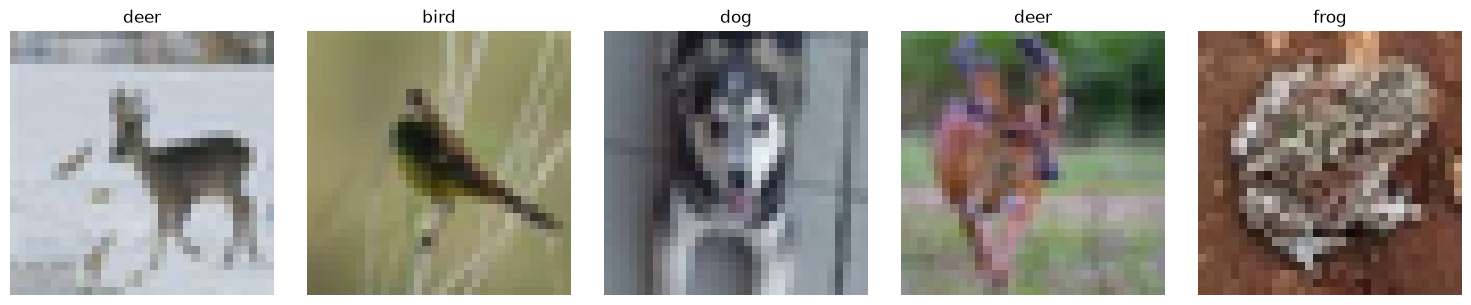

In [4]:
classes = trainset.classes

plt.figure(figsize=(15, 3))

for i in range(5):
    index = random.randint(0, len(trainset) - 1)
    image, label = trainset[index]

    plt.subplot(1, 5, i + 1)
    plt.imshow(image.permute(1, 2, 0))
    plt.title(classes[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

## 5. Datan valmistelu koulutusta varten

Neuroverkkoa ei yleensä kouluteta yhdellä kuvalla kerrallaan.

Sen sijaan kuvat jaetaan pieniin ryhmiin eli **batcheihin**.

Tässä käytämme:

`batch_size = 128`

Tämä tarkoittaa, että mallille annetaan kerralla 128 kuvaa.

`DataLoader` huolehtii datan hakemisesta ja järjestämisestä.

In [5]:
from torch.utils.data import DataLoader

trainloader = DataLoader(
    trainset,
    batch_size=128,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

testloader = DataLoader(
    testset,
    batch_size=128,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

images, labels = next(iter(trainloader))

print("Image batch:", images.shape)
print("Label batch:", labels.shape)

Image batch: torch.Size([128, 3, 32, 32])
Label batch: torch.Size([128])


### Mitä tuloksen pitäisi tarkoittaa?

Jos saat esimerkiksi:

`torch.Size([128, 3, 32, 32])`

se tarkoittaa:

- `128` = kuvaa tässä batchissa
- `3` = RGB-kanavat
- `32` = kuvan korkeus
- `32` = kuvan leveys

Eli:

**128 × 3 × 32 × 32**

kuva-arvoa käsitellään yhtenä batchina.

## 6. Valitaan laskentalaite

Nyt määritetään, käytetäänkö CPU:ta vai GPU:ta.

Seuraava rivi:

`torch.device("cuda" if torch.cuda.is_available() else "cpu")`

valitsee GPU:n, jos sellainen on käytettävissä.

Roihussa tavoitteena on käyttää GPU:ta.

GPU soveltuu erityisen hyvin suuriin rinnakkaisiin laskutoimituksiin,
joita neuroverkkojen koulutuksessa tehdään paljon.

In [6]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GH200 120GB


## 7. Rakennetaan ensimmäinen neuroverkko

Seuraavaksi rakennetaan yksinkertainen CNN eli convolutional neural network.

CNN sopii hyvin kuvien käsittelyyn.

Mallimme tekee kolme pääasiaa:

1. `Conv2d` etsii kuvista ominaisuuksia
2. `MaxPool2d` pienentää käsiteltävän kuvan kokoa
3. `Linear`-kerrokset tekevät lopullisen luokkavalinnan

Mallin ei tarvitse tässä testissä olla erityisen kehittynyt.

Tärkeämpää on, että koko koulutusprosessi toimii Roihussa.

In [7]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = CNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Device:", device)
print("Model:", model)

Device: cuda
Model: CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)


## 8. Mallin kouluttaminen

Nyt pääsemme varsinaiseen koneoppimiseen.

Koulutuksen aikana tapahtuu yksinkertaistettuna seuraavaa:

1. Mallille annetaan kuvia.
2. Malli tekee ennusteen.
3. Ennustetta verrataan oikeaan vastaukseen.
4. Lasketaan virhe (`loss`).
5. Malli päivittää painojaan.
6. Prosessi toistetaan useita kertoja.

Yksi kierros koko koulutusdatan läpi on **epoch**.

Tässä testissä käytämme aluksi viittä epochia.

> Tämä ei ole tarkoitettu parhaimman mahdollisen CIFAR-10-tarkkuuden
> saavuttamiseen, vaan Roihun GPU-ympäristön toiminnan testaamiseen.

In [10]:
for epoch in range(5):
    model.train()

    running_loss = 0.0

    for images, labels in trainloader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    average_loss = running_loss / len(trainloader)

    print(
        f"Epoch {epoch + 1}/5 - "
        f"Loss: {average_loss:.4f}"
    )

Epoch 1/5 - Loss: 0.0825
Epoch 2/5 - Loss: 0.0699
Epoch 3/5 - Loss: 0.0680
Epoch 4/5 - Loss: 0.0710
Epoch 5/5 - Loss: 0.0547


## 9. Testataan mallia uudella datalla

Koulutuksen jälkeen mallia testataan CIFAR-10-testidatalla.

Testidata ei ole mukana mallin koulutuksessa.

Tämän avulla voimme arvioida, kuinka hyvin malli pystyy luokittelemaan
kuvia, joita se ei ole käyttänyt koulutuksen aikana.

`accuracy` kertoo, kuinka suuri osa ennusteista oli oikein.

In [11]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Test accuracy: {accuracy:.2f}%")

Test accuracy: 74.18%


## 10. Yhteenveto

Jos notebook suoritettiin onnistuneesti, olemme testanneet koko
koneoppimisen työketjun:

**Roihu**
↓  
**GPU**
↓  
**PyTorch**
↓  
**CIFAR-10**
↓  
**DataLoader**
↓  
**CNN**
↓  
**GPU-koulutus**
↓  
**Testaus**
↓  
**Accuracy**

Tämän notebookin tärkein tavoite ei ollut saavuttaa mahdollisimman
korkeaa tarkkuutta.

Tärkein tavoite oli todentaa, että Roihun GPU-ympäristö toimii ja että
sillä voidaan suorittaa PyTorch-pohjaista koneoppimista.

### Tämän testin onnistuminen tarkoittaa, että:

- PyTorch toimii
- CUDA toimii
- GPU löytyy
- data voidaan ladata
- data voidaan siirtää GPU:lle
- neuroverkko voidaan kouluttaa
- mallin tulos voidaan arvioida

## 11. Kokeile seuraavaksi

Kun ensimmäinen testi toimii, voit kokeilla esimerkiksi:

### 1. Lisää epochien määrää

Vaihda:

`range(5)`

esimerkiksi:

`range(10)`

Miten test accuracy muuttuu?

### 2. Muuta batch sizea

Kokeile esimerkiksi:

`batch_size=64`

tai:

`batch_size=256`

Miten tämä vaikuttaa koulutukseen?



## 12. Tulosten tulkinta

Kyseessä on tällä hetkellä melko yksinkertainen CNN:

3 convolutional layeria → 2 linear layeria → 10 luokkaa

Joten viiden epochin jälkeen se voi olla jo oppinut suurimman osan siitä, mitä tällä rakenteella ja nykyisellä learning ratella pystyy oppimaan. Loss pienenee harjoituksen edetessä, mutta kehitys alkaa hidastua loppua kohden. Tämä kertoo siitä, että tällä yksinkertaisella mallirakenteella ollaan jo lähellä sitä, mitä nykyisillä asetuksilla on mahdollista saavuttaa.